<a href="https://colab.research.google.com/github/solosolve-ai/solosolve-ai/blob/main/src/notebooks/Gemma3FineTune_ReReWorked_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

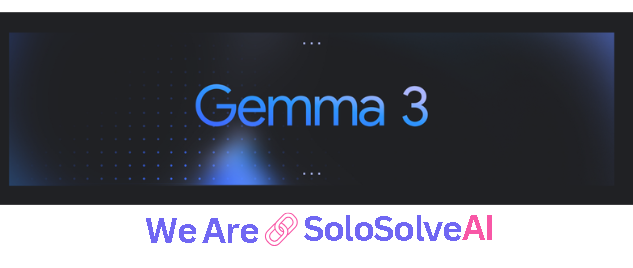

In [18]:
# @title 1. System Setup & Installation
import os
import sys
import logging
from IPython.display import clear_output
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', force=True)

pkgs = [
    "transformers",
    "datasets>=2.14.0",
    "peft>=0.7.0",
    "trl>=0.7.0",
    "accelerate>=0.25.0",
    "bitsandbytes>=0.41.3",
    "deepspeed>=0.14.0",
    "sentencepiece",
    "huggingface_hub",
    "scikit-learn",
    "pandas",
    "matplotlib",
    "seaborn",
    "evaluate",
    "rouge_score"
]

logging.info("Installing dependencies...")
!pip install -q {" ".join(pkgs)}
clear_output()
logging.info("Dependencies installed.")

import torch
logging.info(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    logging.info(f"GPU: {torch.cuda.get_device_name(0)}")
    logging.info(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    logging.warning("No GPU detected. Training will be impossibly slow.")

2025-12-02 15:55:34,505 - INFO - Dependencies installed.
2025-12-02 15:55:34,506 - INFO - PyTorch version: 2.9.0+cu126
2025-12-02 15:55:34,508 - INFO - GPU: Tesla T4
2025-12-02 15:55:34,509 - INFO - Memory: 14.74 GB


In [20]:
# @title 2. Imports & Authentication
import os
import gc
import json
import re
import traceback
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from typing import Dict, List, Optional, Union
import logging
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from transformers import (AutoModelForCausalLM, AutoTokenizer, AutoConfig, BitsAndBytesConfig,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling, logging as hf_logging)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset, Dataset
import evaluate as hf_evaluate

SEED = 42
def set_seed(seed):
    """Sets random seeds for reproducibility across libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(SEED)

from google.colab import userdata
from huggingface_hub import login

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    logging.info("Logged in to Hugging Face successfully.")
except Exception as e:
    logging.warning("HF_TOKEN not found in Colab secrets. Assuming public model or manual login required.")

2025-12-02 15:56:54,961 - INFO - Logged in to Hugging Face successfully.


In [29]:
# @title 3. Project Configuration (The "Edge-Device" Setup)
import os
import torch
import logging

NOTEBOOK_DIR = "."
SFT_DATASET_PATH = "/content/labeled_complaints_gemini-2.5-pro_filtered_4.5k.csv"
STUDENT_MODEL_ID = "google/gemma-3-270m"
run_version = 1
while os.path.exists(os.path.join(NOTEBOOK_DIR, f"gemma-multitask-v{run_version}")):
    run_version += 1
OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, f"gemma-multitask-v{run_version}")
dirs = {
    "model": OUTPUT_DIR,
    "adapter": os.path.join(OUTPUT_DIR, "lora_adapter"),
    "heads": os.path.join(OUTPUT_DIR, "classification_heads.pth"),
    "tokenizer": os.path.join(OUTPUT_DIR, "tokenizer"),
    "logs": os.path.join(OUTPUT_DIR, "logs"),
    "results": os.path.join(OUTPUT_DIR, "results")
}
for d in dirs.values():
    if not d.endswith('.pth'): os.makedirs(d, exist_ok=True)

CONFIG = {
    "lora": {
        "r": 16,
        "alpha": 32,
        # CHANGED: Increased dropout from 0.05 to 0.1 to fight overfitting
        "dropout": 0.1,
        "targets": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    },
    "training": {
        # CHANGED: Increased epochs to 4 because we lowered the learning rate (needs more time)
        "epochs": 4,
        "batch_size": 1,
        # CHANGED: Increased to 16 to stabilize gradients (effectively Batch Size = 16)
        "grad_accum": 16,
        # CHANGED: Lowered LR from 2e-4 to 5e-5 for smoother convergence
        "lr": 5e-5,
        # NEW: Added weight decay to prevent the model from memorizing too hard
        "weight_decay": 0.01,
        "max_grad_norm": 0.3,
        "max_seq_len": 2048,
        "quantization": True
    },
    "loss_weights": {
        # CHANGED: Balanced the weights.
        # Giving more power to LM (2.0) and less to Class (3.0) reduces the "Schizophrenia"
        "lm": 2.0,
        "class": 3.0
    }
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BNB_DTYPE = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
logging.info(f"Config loaded. Model: {STUDENT_MODEL_ID}")
logging.info(f"Loss Config: LM=1.0, Classification=5.0")

2025-12-02 16:50:52,287 - INFO - Config loaded. Model: google/gemma-3-270m
2025-12-02 16:50:52,289 - INFO - Loss Config: LM=1.0, Classification=5.0


In [23]:
# @title 4. Data Preparation & Tokenization
import json
import pandas as pd
from transformers import AutoTokenizer
from datasets import Dataset
import os
import logging

TASKS_CONFIG = {
    "is_actionable": {"type": "binary", "labels": [False, True]},
    "info_complete": {"type": "binary", "labels": [False, True]},
    "complaint_category": {
        "type": "multi_class",
        "labels": ["Damaged or Defective", "Item Not as Described", "Incorrect Size / Fit", "Wrong or Incomplete Order", "N/A"]
    },
    "resolution_recommendation": {
        "type": "multi_class",
        "labels": ["Full Refund", "Replacement", "Resend", "N/A"]
    }
}

LABEL_TO_ID = {}
for task, info in TASKS_CONFIG.items():
    LABEL_TO_ID[task] = {label: idx for idx, label in enumerate(info['labels'])}
    if info['type'] == "binary":
        LABEL_TO_ID[task].update({"1": 1, "0": 0, 1: 1, 0: 0, "True": 1, "False": 0})

logging.info(f"Loading Tokenizer: {STUDENT_MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

if not os.path.exists(SFT_DATASET_PATH):
    logging.warning(f"Dataset not found at {SFT_DATASET_PATH}. Please upload it!")
else:
    logging.info(f"Loading dataset from {SFT_DATASET_PATH}...")
    df = pd.read_csv(SFT_DATASET_PATH)
df['text'] = df['text'].fillna("")
df['product_title'] = df['product_title'].fillna("Unknown Product")

def format_multitask_sample(row):
    """Formats a single row into a multitask sample for training."""
    try:
        price_str = f"${float(row.get('price', 0)):.2f}"
    except:
        price_str = "N/A"
    prompt = (
        f"<start_of_turn>user\n"
        f"Analyze this Amazon Fashion complaint:\n"
        f"Product: {row.get('product_title')}\n"
        f"Price: {price_str}\n"
        f"Rating: {row.get('rating')}/5\n"
        f"Complaint: \"{row.get('text')}\"\n"
        f"<end_of_turn>\n"
        f"<start_of_turn>model\n"
    )
    target_json = json.dumps({
        "category": row.get('complaint_category', 'N/A'),
        "resolution": row.get('resolution_recommendation', 'N/A'),
        "actionable": bool(row.get('is_actionable')),
        "complete": bool(row.get('info_complete'))
    }, ensure_ascii=False)
    full_text = prompt + target_json + tokenizer.eos_token
    prompt_tokens = tokenizer(prompt, add_special_tokens=False)['input_ids']
    mask_len = len(prompt_tokens)
    labels = {}
    for task in TASKS_CONFIG:
        val = row.get(task)
        labels[f"label_{task}"] = LABEL_TO_ID[task].get(val, -100)
    return {
        "text_for_lm": full_text,
        "prompt_len": mask_len,
        **labels
    }

logging.info("Processing dataset...")
dataset = Dataset.from_pandas(df)
dataset = dataset.map(format_multitask_sample)
dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = dataset['train']
eval_dataset = dataset['test']

logging.info(f"Data Ready. Train: {len(train_dataset)} | Eval: {len(eval_dataset)}")

2025-12-02 15:57:29,253 - INFO - Loading Tokenizer: google/gemma-3-270m...
2025-12-02 15:57:39,403 - INFO - Loading dataset from /content/labeled_complaints_gemini-2.5-pro_filtered_4.5k.csv...
2025-12-02 15:57:39,615 - INFO - Processing dataset...


Map:   0%|          | 0/4545 [00:00<?, ? examples/s]

2025-12-02 15:57:51,188 - INFO - Data Ready. Train: 4090 | Eval: 455


2025-12-02 15:58:29,918 - INFO - Analyzing Dataset Distributions...
2025-12-02 15:58:29,976 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-12-02 15:58:29,992 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-12-02 15:58:30,043 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-12-02 15:58:30,057 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


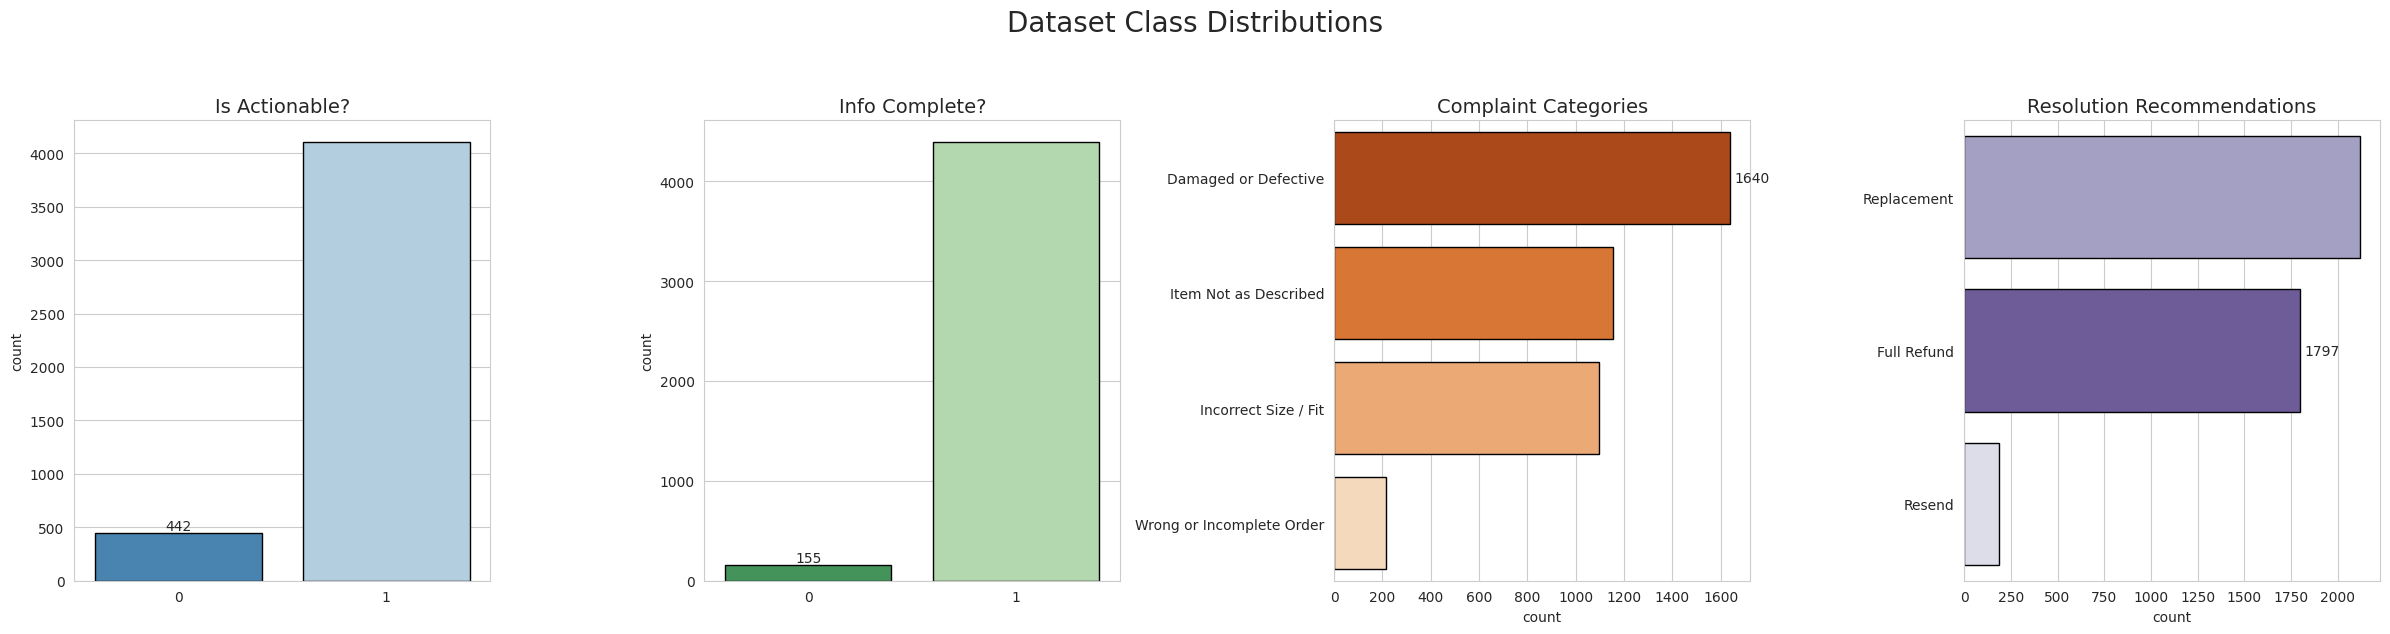

2025-12-02 15:58:30,661 - INFO - INSIGHT: Class imbalance is present, but our Weighted Loss strategy mitigates bias.


In [24]:
# @title 4.5. Exploratory Data Analysis (The "Data Landscape")
import matplotlib.pyplot as plt
import seaborn as sns
import logging

logging.info("Analyzing Dataset Distributions...")
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle("Dataset Class Distributions", fontsize=20, y=1.05)
palettes = ['Blues_r', 'Greens_r', 'Oranges_r', 'Purples_r']
sns.countplot(x='is_actionable', data=df, ax=axes[0], hue='is_actionable', palette=palettes[0], edgecolor='black', legend=False)
axes[0].set_title("Is Actionable?", fontsize=14)
axes[0].set_xlabel("")
axes[0].bar_label(axes[0].containers[0])
sns.countplot(x='info_complete', data=df, ax=axes[1], hue='info_complete', palette=palettes[1], edgecolor='black', legend=False)
axes[1].set_title("Info Complete?", fontsize=14)
axes[1].set_xlabel("")
axes[1].bar_label(axes[1].containers[0])
sns.countplot(y='complaint_category', data=df, ax=axes[2], hue='complaint_category',
              order=df['complaint_category'].value_counts().index,
              palette=palettes[2], edgecolor='black', legend=False)
axes[2].set_title("Complaint Categories", fontsize=14)
axes[2].set_ylabel("")
axes[2].bar_label(axes[2].containers[0], padding=3)
sns.countplot(y='resolution_recommendation', data=df, ax=axes[3], hue='resolution_recommendation',
              order=df['resolution_recommendation'].value_counts().index,
              palette=palettes[3], edgecolor='black', legend=False)
axes[3].set_title("Resolution Recommendations", fontsize=14)
axes[3].set_ylabel("")
axes[3].bar_label(axes[3].containers[0], padding=3)
plt.tight_layout()
plt.show()
logging.info("INSIGHT: Class imbalance is present, but our Weighted Loss strategy mitigates bias.")

In [28]:
# @title 5. Data Collator prepares raw samples into a unified batch by tokenizing, padding, and applying loss masking for stable multi-task training. It pads/truncates sequences to fixed length, masks prompt/pad tokens with `-100` to exclude them from LM loss, and attaches classification labels so both LM and auxiliary tasks are trained in a single forward pass.
import logging

class MultiTaskDataCollator:
    """Data collator for multi-task training, handling both language modeling and classification labels."""
    def __init__(self, tokenizer, max_len=2048):
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __call__(self, features):
        texts = [f["text_for_lm"] for f in features]
        prompt_lens = [f["prompt_len"] for f in features]
        batch = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        labels = batch["input_ids"].clone()
        for i, prompt_len in enumerate(prompt_lens):
            mask_end = min(prompt_len, self.max_len)
            labels[i, :mask_end] = -100
        if self.tokenizer.pad_token_id is not None:
            labels[labels == self.tokenizer.pad_token_id] = -100
        batch["labels"] = labels
        for key in features[0].keys():
            if key.startswith("label_"):
                values = [f[key] for f in features]
                batch[key] = torch.tensor(values, dtype=torch.long)
        return batch

logging.info("Data Collator defined.")

2025-12-02 16:16:20,037 - INFO - Data Collator defined.


# GemmaMultiTask: A Multi-Task Adaptation of Gemma-3 270M

# GemmaMultiTask: Compact Technical Overview

**Model:** Gemma-3 270M adapted with LoRA + multi-task heads  
**Use Case:** Short-text NLU (e.g., complaint analysis) with mixed generation + classification  
**Specs:** 271.9M params base, ~3.8M trainable via LoRA, 4-bit NF4 quantized (~180MB)

## 1. Summary
GemmaMultiTask wraps **Gemma3ForCausalLM** with **four classification heads**.  
It supports sequences up to **32k tokens**, uses **hybrid attention** (sliding + periodic full), and applies **RoPE** for relative positions.  
Designed for low-resource distillation from larger teacher models (e.g., Gemini).

## 2. Key Configuration (Gemma3TextConfig)
- **hidden_size:** 640  
- **intermediate_size:** 2048  
- **num_layers:** 18  
- **num_heads / num_kv_heads:** 4 / 1 (MQA)  
- **sliding_window:** 512  
- **layer_types:** sliding attention except layers 6, 12, 18 (full)  
- **max_pos:** 32768  
- **dtype:** bfloat16  
- **rope_theta:** 1e6  
- **quantization:** NF4 + double quant, compute bfloat16  

**Effect:** O(N × 512) attention cost for most layers, enabling long-context on edge devices.

## 3. Architecture (Condensed)
**Embeddings:** 262k vocab → 640 dims + RoPE  
**Decoder (×18):**
- MQA attention (LoRA on q/k/v/o projections)  
- Sliding/full attention mix  
- MLP (640 → 2048 → 640) with GELU-Tanh  
- RMSNorm throughout  

**Outputs:**  
- **LM head** for generation  
- **4 classification heads:** actionable, complete, category, recommendation  

## 4. LoRA Adaptation
Only small low-rank matrices are trained:  
- r=16, α=32  
- Applied to q/k/v/o and MLP projections  
- Trainable ratio: **1.4%**

## 5. Training Logic
- Optimizer: paged AdamW 8-bit  
- Loss: LM cross-entropy (masked with −100) + CE for each head  
- Single forward pass produces both generation logits and classification logits.

## 6. Inference
- Fast MQA + KV cache  
- Shared encoder → branching to LM + heads  
- Suitable for mobile/edge deployment.



In [26]:
# @title 6. Custom Multi-Task Architecture (Weighted Loss Edition)
import torch.nn as nn
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig
import logging
import io
import sys

class GemmaMultiTask(nn.Module):
    """Custom Multi-Task model combining a CausalLM with classification heads."""
    def __init__(self, model_id, tasks_config, loss_weights, quantization=True):
        """Initializes the GemmaMultiTask model.

        Args:
            model_id (str): The identifier for the base CausalLM model.
            tasks_config (dict): Configuration for each classification task.
            loss_weights (dict): Weights for LM and classification losses.
            quantization (bool): Whether to use 4-bit quantization for the base model.
        """
        super().__init__()
        self.loss_weights = loss_weights
        bnb_config = None
        if quantization:
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_use_double_quant=True,
                bnb_4bit_compute_dtype=BNB_DTYPE
            )
        self.base_model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            torch_dtype=BNB_DTYPE,
            device_map={"": 0} if torch.cuda.is_available() else "cpu",
            trust_remote_code=True
        )
        self.hidden_size = self.base_model.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.heads = nn.ModuleDict()
        for task, info in tasks_config.items():
            self.heads[task] = nn.Linear(self.hidden_size, len(info['labels']))
        logging.info("Model Architecture: Base Gemma + %s Classification Heads", len(self.heads))

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        """Performs a forward pass through the model.

        Args:
            input_ids (torch.Tensor): Input token IDs.
            attention_mask (torch.Tensor, optional): Attention mask.
            labels (torch.Tensor, optional): Language modeling labels.
            **kwargs: Additional keyword arguments for classification task labels.

        Returns:
            dict: A dictionary containing the total loss, LM logits, and classification logits.
        """
        outputs = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            output_hidden_states=True,
            return_dict=True
        )
        lm_loss = outputs.loss if outputs.loss is not None else 0
        total_loss = lm_loss * self.loss_weights.get('lm', 1.0)
        last_hidden_state = outputs.hidden_states[-1]
        if attention_mask is not None:
            last_idx = attention_mask.sum(dim=1) - 1
            pooled_output = last_hidden_state[torch.arange(last_hidden_state.shape[0]), last_idx]
        else:
            pooled_output = last_hidden_state[:, -1, :]
        pooled_output = self.dropout(pooled_output)
        logits_dict = {}
        class_weight = self.loss_weights.get('class', 5.0)
        for task, head in self.heads.items():
            logits = head(pooled_output)
            logits_dict[f"logits_{task}"] = logits
            label_key = f"label_{task}"
            if label_key in kwargs and kwargs[label_key] is not None:
                task_labels = kwargs[label_key]
                loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
                task_loss = loss_fct(logits, task_labels)
                if not torch.isnan(task_loss):
                    total_loss += (task_loss * class_weight)
        return {
            "loss": total_loss,
            "logits": outputs.logits,
            **logits_dict
        }

    def gradient_checkpointing_enable(self, gradient_checkpointing_kwargs=None):
        """Enables gradient checkpointing for the base model."""
        self.base_model.gradient_checkpointing_enable(gradient_checkpointing_kwargs=gradient_checkpointing_kwargs)

    def save_pretrained(self, save_directory):
        """Saves the base model's pretrained weights."""
        self.base_model.save_pretrained(save_directory)

logging.info("Instantiating Model...")
model_wrapper = GemmaMultiTask(
    STUDENT_MODEL_ID,
    TASKS_CONFIG,
    loss_weights=CONFIG['loss_weights'],
    quantization=CONFIG['training']['quantization']
)

logging.info("Applying LoRA Adapters...")
peft_config = LoraConfig(
    task_type="CAUSAL_LM",
    inference_mode=False,
    r=CONFIG['lora']['r'],
    lora_alpha=CONFIG['lora']['alpha'],
    lora_dropout=CONFIG['lora']['dropout'],
    target_modules=CONFIG['lora']['targets']
)
model_wrapper.base_model = get_peft_model(model_wrapper.base_model, peft_config)

# Capture and log trainable parameters
original_stdout = sys.stdout
sys.stdout = buffer = io.StringIO()
try:
    model_wrapper.base_model.print_trainable_parameters()
finally:
    sys.stdout = original_stdout # Restore stdout using the original reference
logging.info("Trainable Parameters Summary:\n" + buffer.getvalue().strip())

model_wrapper.base_model.enable_input_require_grads()
model_wrapper.gradient_checkpointing_enable()

# Log Model Architecture and Specifications
logging.info("\nModel Architecture and Specifications:\n" + str(model_wrapper.base_model.config))
logging.info("\nModel Summary:\n" + str(model_wrapper))

logging.info("Model Ready for Training.")

2025-12-02 15:58:54,496 - INFO - Instantiating Model...
2025-12-02 15:58:55,811 - INFO - Model Architecture: Base Gemma + 4 Classification Heads
2025-12-02 15:58:55,820 - INFO - Applying LoRA Adapters...
2025-12-02 15:58:55,997 - INFO - Trainable Parameters Summary:
trainable params: 3,796,992 || all params: 271,895,168 || trainable%: 1.3965
2025-12-02 15:58:56,002 - INFO - 
Model Architecture and Specifications:
Gemma3TextConfig {
  "_sliding_window_pattern": 6,
  "architectures": [
    "Gemma3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "attn_logit_softcapping": null,
  "bos_token_id": 2,
  "dtype": "bfloat16",
  "eos_token_id": 1,
  "final_logit_softcapping": null,
  "head_dim": 256,
  "hidden_activation": "gelu_pytorch_tanh",
  "hidden_size": 640,
  "initializer_range": 0.02,
  "intermediate_size": 2048,
  "layer_types": [
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "sliding_attention",
    "f

In [ ]:
# @title 7. Training Execution (Final Fix: Disable Safetensors)
import traceback
import logging
from transformers import TrainingArguments, Trainer

logging.info("Configuring Trainer...")
training_args = TrainingArguments(
    output_dir=dirs['logs'],
    per_device_train_batch_size=CONFIG['training']['batch_size'],
    gradient_accumulation_steps=CONFIG['training']['grad_accum'],
    learning_rate=CONFIG['training']['lr'],
    num_train_epochs=CONFIG['training']['epochs'],
    logging_steps=10,
    optim="paged_adamw_8bit",
    save_strategy="epoch",
    eval_strategy="epoch",
    save_total_limit=2,
    bf16=True,
    max_grad_norm=CONFIG['training']['max_grad_norm'],
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    group_by_length=False,
    report_to="none",
    ddp_find_unused_parameters=False,
    remove_unused_columns=False,
    label_names=["labels"] + [f"label_{t}" for t in TASKS_CONFIG.keys()],
    save_safetensors=False
)
trainer = Trainer(
    model=model_wrapper,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=MultiTaskDataCollator(tokenizer, max_len=CONFIG['training']['max_seq_len'])
)
logging.info(f"Starting Training (Epochs: {CONFIG['training']['epochs']})...")
try:
    train_result = trainer.train()
    training_success = True
except Exception as e:
    logging.error(f"Training Failed: {e}")
    traceback.print_exc()
    training_success = False

if training_success:
    logging.info("Saving Artifacts...")
    trainer.save_model(dirs['adapter'])
    head_state_dict = model_wrapper.heads.state_dict()
    torch.save(head_state_dict, dirs['heads'])
    tokenizer.save_pretrained(dirs['tokenizer'])
    metrics = train_result.metrics
    trainer.log_metrics("train", metrics)
    trainer.save_metrics("train", metrics)
    trainer.save_state()
    logging.info(f"DONE. Model version {run_version} is ready for evaluation.")
else:
    logging.warning("Training crashed.")

🚀 Configuring Trainer...


/tmp/ipython-input-3328110785.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


🔥 Starting Training (Epochs: 3)...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,0.507000,0.384250
2,0.133600,0.377461
3,0.150700,0.367998


💾 Saving Artifacts...
***** train metrics *****
  epoch                    =        3.0
  total_flos               =        0GF
  train_loss               =     4.3502
  train_runtime            = 1:16:52.38
  train_samples_per_second =       2.66
  train_steps_per_second   =      0.333

✨ DONE. Model version 1 is ready for evaluation.


📊 Analyzing Training Dynamics...
   Found 153 training steps and 3 evaluation points.


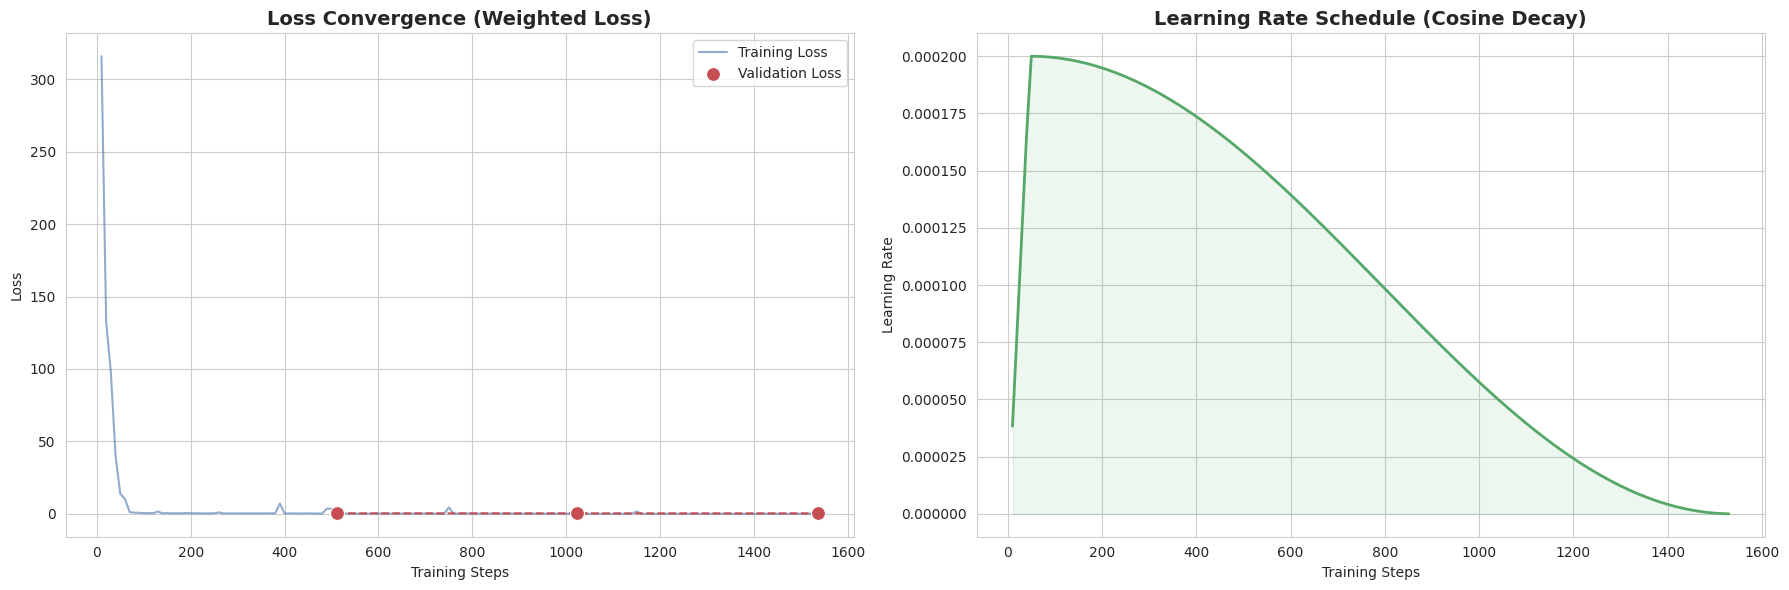

💡 INTERPRETATION:
1. If Training Loss < Validation Loss: The model is memorizing (Overfitting).
2. If Validation Loss plateaus: Further training yields diminishing returns.
3. Note the Weighted Loss scale: Values are higher than standard LM loss due to the 5x classification penalty.


In [ ]:
# @title 8. Training Dynamics Analysis
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import logging

logging.info("Analyzing Training Dynamics...")
log_path = os.path.join(dirs['logs'], "trainer_state.json")
if os.path.exists(log_path):
    with open(log_path, "r") as f:
        data = json.load(f)
    history = data['log_history']
    df_logs = pd.DataFrame(history)
    train_logs = df_logs.dropna(subset=['loss']).reset_index()
    eval_logs = df_logs.dropna(subset=['eval_loss']).reset_index()
    logging.info(f"Found {len(train_logs)} training steps and {len(eval_logs)} evaluation points.")
    sns.set_style("whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    sns.lineplot(data=train_logs, x='step', y='loss', ax=ax1, label='Training Loss', color='#4C72B0', alpha=0.6)
    if not eval_logs.empty:
        sns.scatterplot(data=eval_logs, x='step', y='eval_loss', ax=ax1, color='#C44E52', s=100, label='Validation Loss', zorder=5)
        sns.lineplot(data=eval_logs, x='step', y='eval_loss', ax=ax1, color='#C44E52', linestyle='--')
    ax1.set_title("Loss Convergence (Weighted Loss)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Training Steps")
    ax1.set_ylabel("Loss")
    ax1.legend()
    if 'learning_rate' in train_logs.columns:
        sns.lineplot(data=train_logs, x='step', y='learning_rate', ax=ax2, color='#55A868', linewidth=2)
        ax2.set_title("Learning Rate Schedule (Cosine Decay)", fontsize=14, fontweight='bold')
        ax2.set_xlabel("Training Steps")
        ax2.set_ylabel("Learning Rate")
        ax2.fill_between(train_logs['step'], train_logs['learning_rate'], color='#55A868', alpha=0.1)
    plt.tight_layout()
    plt.savefig(os.path.join(dirs['results'], "training_dynamics.png"))
    plt.show()
    logging.info("INTERPRETATION:")
    logging.info("1. If Training Loss < Validation Loss: The model is memorizing (Overfitting).")
    logging.info("2. If Validation Loss plateaus: Further training yields diminishing returns.")
    logging.info("3. Note the Weighted Loss scale: Values are higher than standard LM loss due to the 5x classification penalty.")
else:
    logging.warning("No training logs found. Did training finish successfully?")

🚀 Loading Model for Final Evaluation...
🧠 Model Architecture: Base Gemma + 4 Classification Heads
📊 Collecting Metrics & Confidence Scores...


Testing:   0%|          | 0/114 [00:00<?, ?it/s]


🎨 Generating Confidence Distributions...


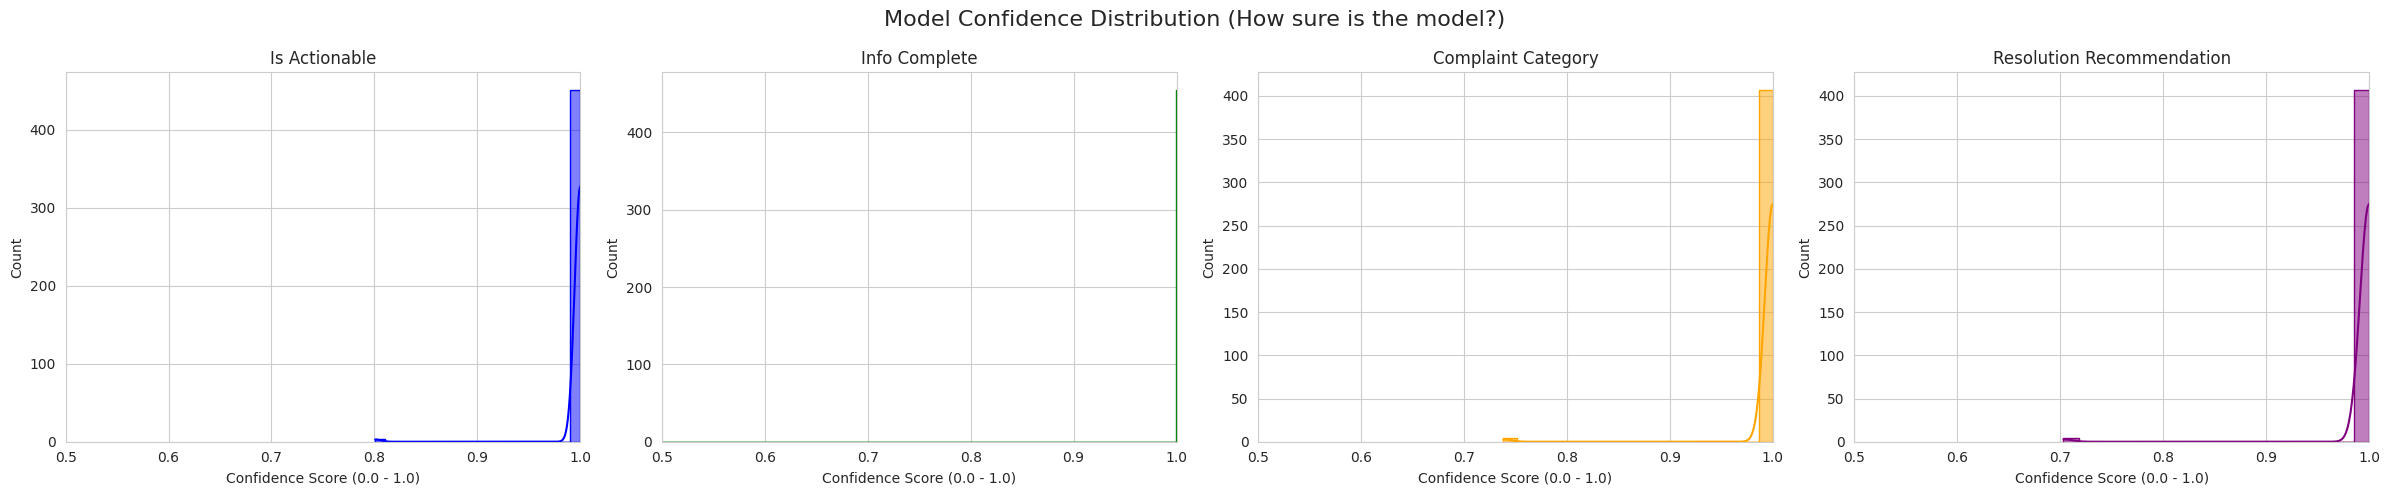

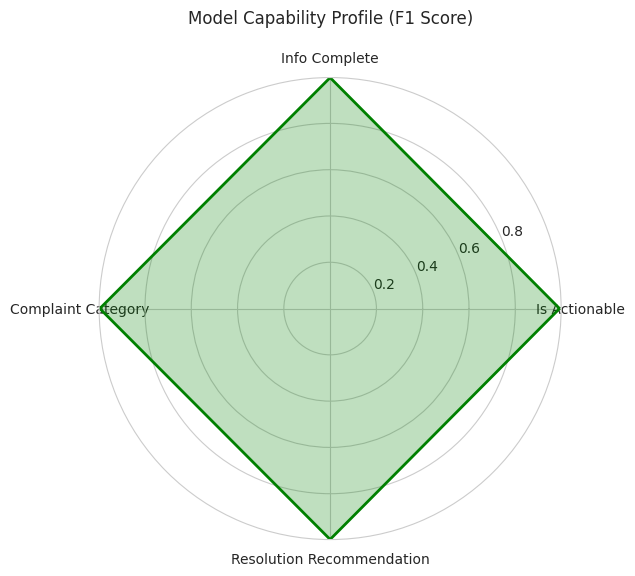


🕵️‍♂️ --- LIVE STRESS TEST ---

📝 Input Prompt:
--------------------
<start_of_turn>user
Analyze this Amazon Fashion complaint:
Product: Nike Air Zoom Pegasus 39
Price: $120.00
Rating: 1/5
Complaint: "I ordered the blue running shoes in size 10, but you sent me red sandals in size 8! This is ridiculous, I have a marathon tomorrow. I want my money back immediately."
<end_of_turn>
<start_of_turn>model
--------------------

🧠 Model Thinking (Classification Heads):
   • IS_ACTIONABLE             -> 1                         (100.0% ✅)
   • INFO_COMPLETE             -> 1                         (100.0% ✅)
   • COMPLAINT_CATEGORY        -> Item Not as Described     (99.6% ✅)
   • RESOLUTION_RECOMMENDATION -> Resend                    (89.8% ✅)

✍️  Generating JSON...

user
Analyze this Amazon Fashion complaint:
Product: Nike Air Zoom Pegasus 39
Price: $120.00
Rating: 1/5
Complaint: "I ordered the blue running shoes in size 10, but you sent me red sandals in size 8! This is ridiculous, I hav

In [ ]:
# @title 9. Final Evaluation & Live Stress Test (Visual Edition and Stress Test)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gc
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from tqdm.auto import tqdm
from peft import get_peft_model, LoraConfig
import logging

gc.collect()
torch.cuda.empty_cache()
logging.info("Loading Model for Final Evaluation...")
inference_model = GemmaMultiTask(STUDENT_MODEL_ID, TASKS_CONFIG, CONFIG['loss_weights'], CONFIG['training']['quantization'])
peft_config = LoraConfig(task_type="CAUSAL_LM", inference_mode=True, r=CONFIG['lora']['r'], lora_alpha=CONFIG['lora']['alpha'], lora_dropout=CONFIG['lora']['dropout'], target_modules=CONFIG['lora']['targets'])
inference_model.base_model = get_peft_model(inference_model.base_model, peft_config)
adapter_path = os.path.join(dirs['adapter'], "pytorch_model.bin")
if os.path.exists(adapter_path): inference_model.load_state_dict(torch.load(adapter_path, map_location=DEVICE), strict=False)
head_path = dirs['heads']
if os.path.exists(head_path):
    inference_model.heads.load_state_dict(torch.load(head_path, map_location=DEVICE))
    inference_model.heads.to(dtype=BNB_DTYPE, device=DEVICE)
inference_model.to(DEVICE)
inference_model.eval()
logging.info("Collecting Metrics & Confidence Scores...")
predictions = {task: [] for task in TASKS_CONFIG}
ground_truths = {task: [] for task in TASKS_CONFIG}
confidences = {task: [] for task in TASKS_CONFIG}
test_loader = torch.utils.data.DataLoader(eval_dataset, batch_size=4, collate_fn=MultiTaskDataCollator(tokenizer, max_len=CONFIG['training']['max_seq_len']))
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = inference_model(**batch)
        for task in TASKS_CONFIG:
            probs = torch.softmax(outputs[f"logits_{task}"], dim=-1)
            preds = torch.argmax(probs, dim=-1).cpu().numpy()
            labels = batch[f"label_{task}"].cpu().numpy()
            batch_conf = torch.max(probs, dim=-1).values.float().cpu().numpy()
            valid = labels != -100
            predictions[task].extend(preds[valid])
            ground_truths[task].extend(labels[valid])
            confidences[task].extend(batch_conf[valid])
logging.info("Generating Confidence Distributions...")
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle(f"Model Confidence Distribution (How sure is the model?)", fontsize=16)
colors = ['blue', 'green', 'orange', 'purple']
for i, task in enumerate(TASKS_CONFIG):
    sns.histplot(confidences[task], bins=20, ax=axes[i], color=colors[i], kde=True, element="step")
    axes[i].set_title(task.replace('_', ' ').title())
    axes[i].set_xlabel("Confidence Score (0.0 - 1.0)")
    axes[i].set_xlim(0.5, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(dirs['results'], "confidence_distribution.png"))
plt.show()
metrics_summary = {}
for task in TASKS_CONFIG:
    f1 = precision_recall_fscore_support(ground_truths[task], predictions[task], average='weighted', zero_division=0)[2]
    metrics_summary[task] = f1
labels = [t.replace('_', ' ').title() for t in TASKS_CONFIG]
stats = list(metrics_summary.values()) + [list(metrics_summary.values())[0]]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist() + [0]
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)
ax.fill(angles, stats, color='green', alpha=0.25)
ax.plot(angles, stats, color='green', linewidth=2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title(f"Model Capability Profile (F1 Score)", y=1.1)
plt.savefig(os.path.join(dirs['results'], "radar_chart.png"))
plt.show()
logging.info("--- LIVE STRESS TEST ---")
custom_complaint = {
    "text": "I ordered the blue running shoes in size 10, but you sent me red sandals in size 8! This is ridiculous, I have a marathon tomorrow. I want my money back immediately.",
    "product_title": "Nike Air Zoom Pegasus 39", "price": 120.00, "rating": 1
}
formatted = format_multitask_sample({**custom_complaint, "is_actionable": 0, "info_complete": 0, "complaint_category": "N/A", "resolution_recommendation": "N/A"})
prompt_text = formatted['text_for_lm'].split("<start_of_turn>model")[0] + "<start_of_turn>model\n"
inputs = tokenizer(prompt_text, return_tensors="pt").to(DEVICE)
logging.info(f"Input Prompt:\n{'-'*20}\n{prompt_text.strip()}\n{'-'*20}")
with torch.no_grad():
    outputs = inference_model(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask)
    logging.info("Model Thinking (Classification Heads):")
    for task in TASKS_CONFIG:
        logit = outputs[f"logits_{task}"][0]
        pred_idx = torch.argmax(logit).item()
        pred_label = TASKS_CONFIG[task]['labels'][pred_idx]
        confidence = torch.softmax(logit, dim=0)[pred_idx].item()
        indicator = " (HIGH CONFIDENCE)" if confidence > 0.8 else " (LOW CONFIDENCE)"
        logging.info(f"   * {task.upper():<25} -> {pred_label:<25} ({confidence:.1%}{indicator})")
    logging.info("Generating JSON...")
    gen_tokens = inference_model.base_model.generate(**inputs, max_new_tokens=64, do_sample=False)
    logging.info(tokenizer.decode(gen_tokens[0], skip_special_tokens=True).split('model\n')[-1])